# 10 — K-Nearest Neighbors Regression
**Course:** 23CSE301 Machine Learning — Capstone Project  
**Review:** Review 1 — Regression  
**Dataset:** `diamonds_sampled.csv`

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

RANDOM_STATE = 42
TEST_SIZE = 0.20

def resolve_file(filename):
    candidates = [
        Path("../data") / filename,
        Path("data") / filename,
        Path("/mnt/data") / filename,
        Path(filename)
    ]
    for p in candidates:
        if p.exists():
            return p
    raise FileNotFoundError(f"Could not find {filename}")

class IQRClipper(BaseEstimator, TransformerMixin):
    def __init__(self, factor=1.5):
        self.factor = factor
    def fit(self, X, y=None):
        X = np.asarray(X, dtype=float)
        self.q1_ = np.nanpercentile(X, 25, axis=0)
        self.q3_ = np.nanpercentile(X, 75, axis=0)
        iqr = self.q3_ - self.q1_
        self.lower_ = self.q1_ - self.factor * iqr
        self.upper_ = self.q3_ + self.factor * iqr
        return self
    def transform(self, X):
        return np.clip(np.asarray(X, dtype=float), self.lower_, self.upper_)

In [2]:
DATA_PATH = resolve_file("diamonds_sampled.csv")
TARGET = "price"
df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.dtypes.to_frame("dtype"))
print("\nMissing values:")
display(df.isnull().sum().to_frame("missing"))
print("\nDuplicate rows:", df.duplicated().sum())
print("\nTarget summary:")
display(df[TARGET].describe().to_frame("price"))
display(df.head())

Shape: (2100, 11)


,dtype
id: 0,int64
carat,float64
cut,str
color,str
clarity,str
depth,float64
table,float64
price,int64
x,float64
y,float64



Missing values:


,missing
id: 0,0
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0



Duplicate rows: 0

Target summary:


,price
count,2100.000000
mean,3971.387143
std,4124.225067
min,360.000000
25%,926.750000
50%,2324.500000
75%,5357.250000
max,18803.000000


,id: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1389,0.24,Ideal,G,VVS1,62.1,56.0,559,3.97,4.00,2.47
1,50053,0.58,Very Good,F,VVS2,60.0,57.0,2201,5.44,5.42,3.26
2,41646,0.40,Ideal,E,VVS2,62.1,55.0,1238,4.76,4.74,2.95
3,42378,0.43,Premium,E,VVS2,60.8,57.0,1304,4.92,4.89,2.98
4,17245,1.55,Ideal,E,SI2,62.3,55.0,6901,7.44,7.37,4.61


### A1 observation — write a dataset-specific observation using the actual output.

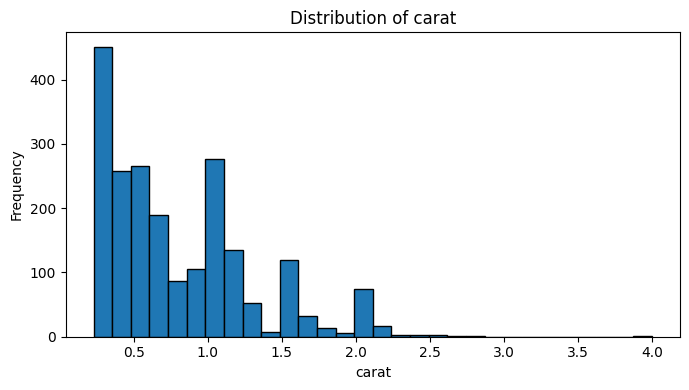

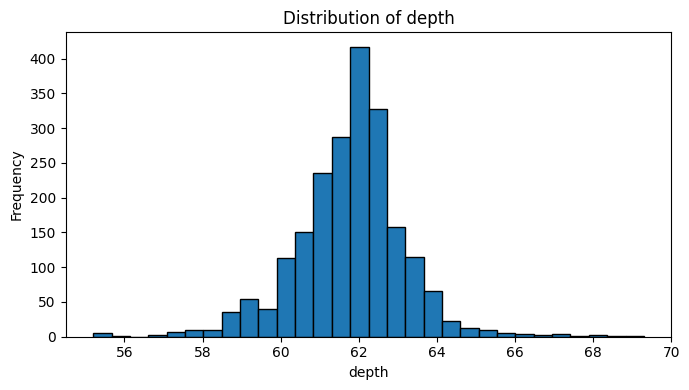

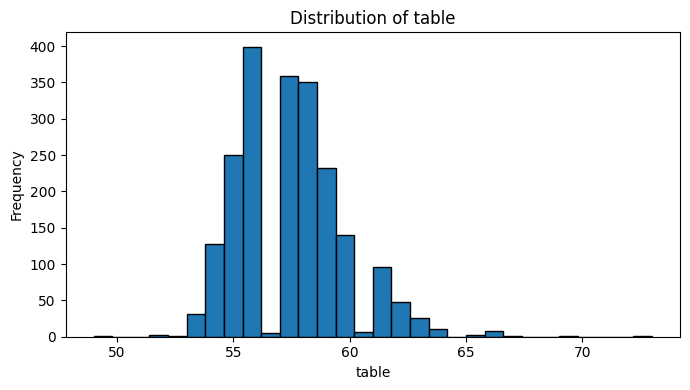

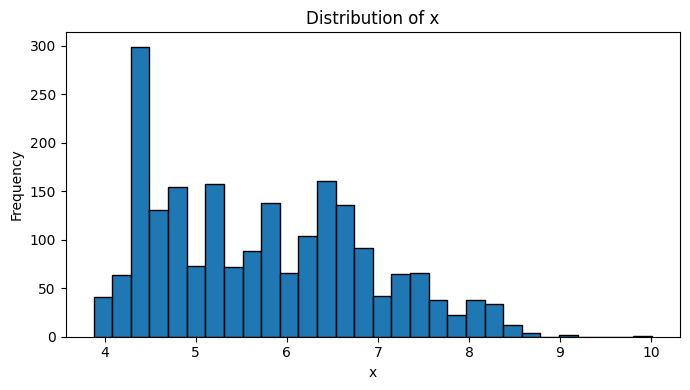

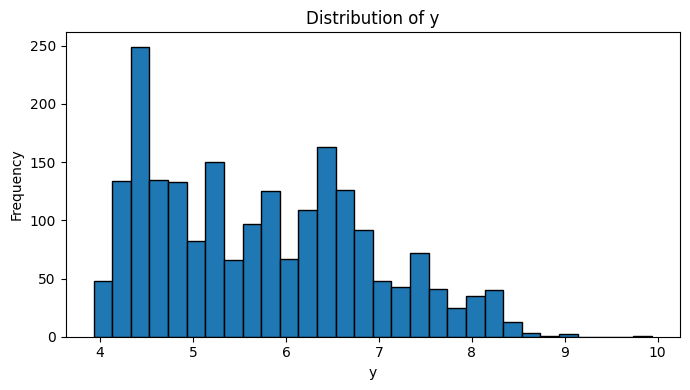

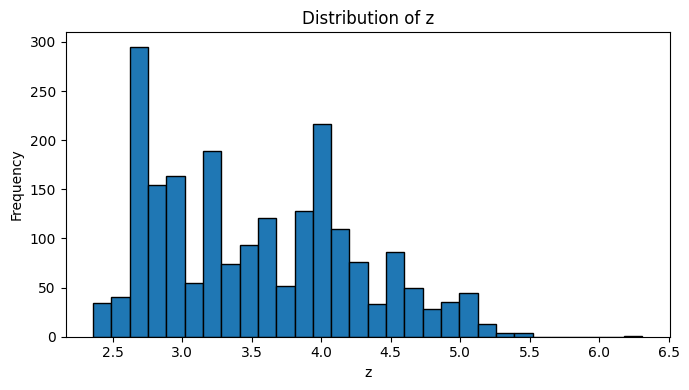

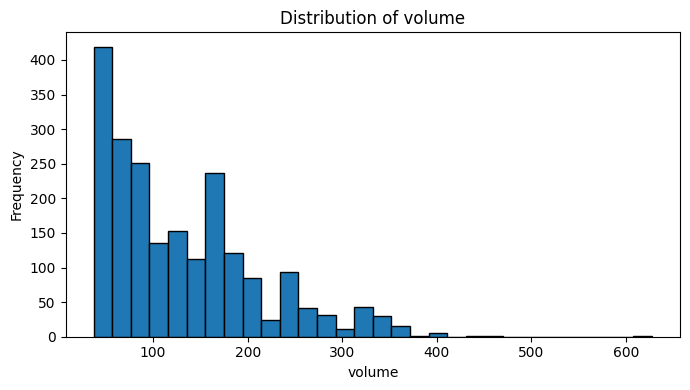

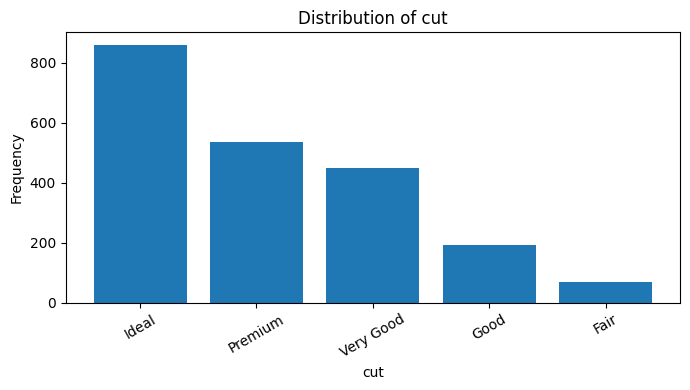

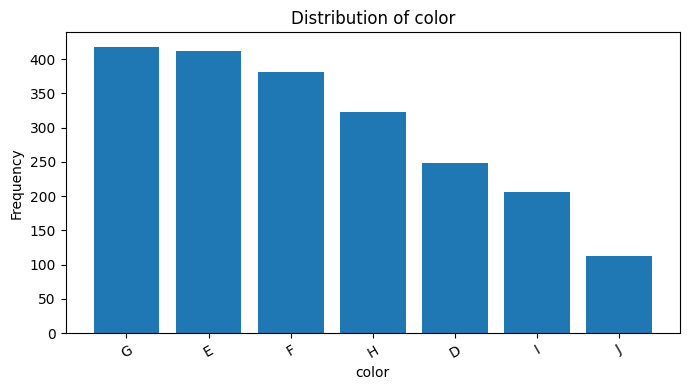

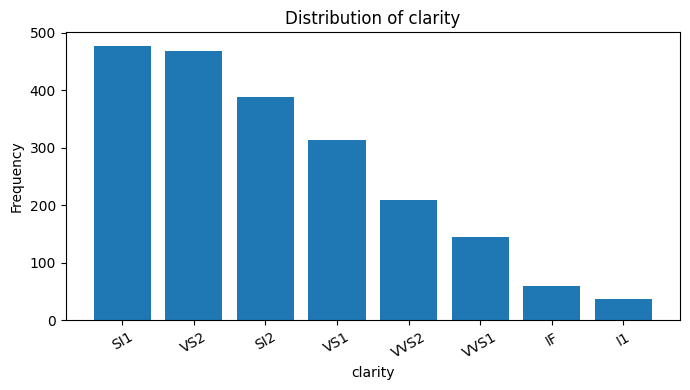

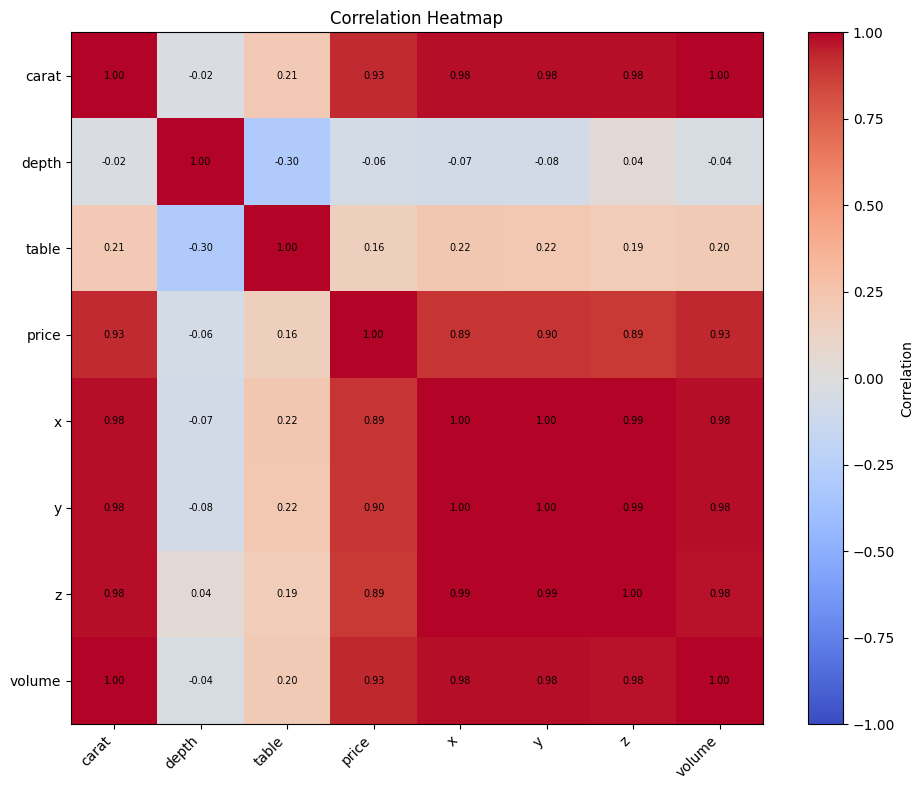

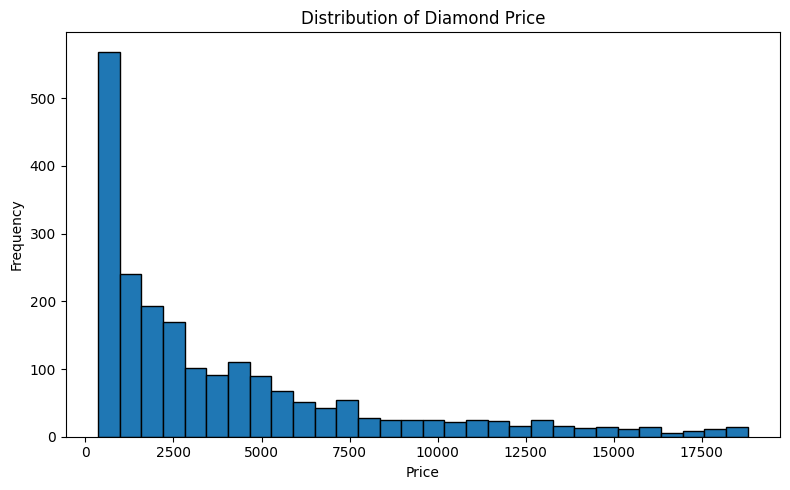

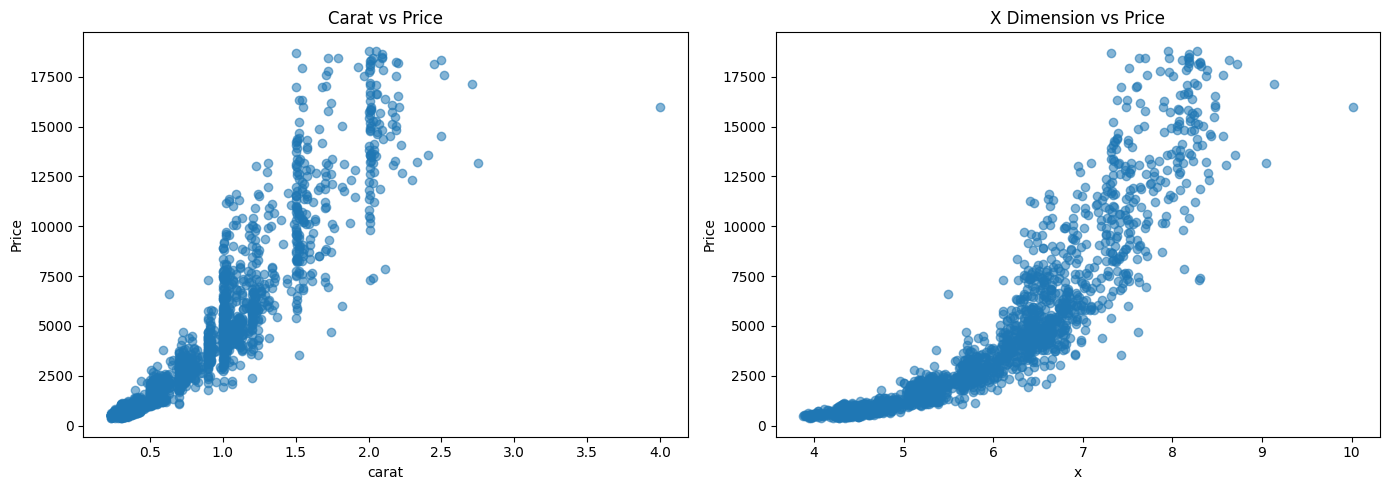

In [3]:
df = df.copy()
df = df.drop(columns=["id: 0"], errors="ignore")
df["volume"] = df["x"] * df["y"] * df["z"]

numeric_cols = [c for c in df.select_dtypes(include=np.number).columns if c != TARGET]
categorical_cols = df.select_dtypes(include="object").columns.tolist()

for col in numeric_cols:
    plt.figure(figsize=(7,4))
    plt.hist(df[col].dropna(), bins=30, edgecolor="black")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

for col in categorical_cols:
    counts = df[col].value_counts()
    plt.figure(figsize=(7,4))
    plt.bar(counts.index.astype(str), counts.values)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.show()

corr = df.select_dtypes(include=np.number).corr()
fig, ax = plt.subplots(figsize=(10,8))
im = ax.imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha="right")
ax.set_yticklabels(corr.columns)
fig.colorbar(im, ax=ax, label="Correlation")
ax.set_title("Correlation Heatmap")
for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        ax.text(j, i, f"{corr.iloc[i,j]:.2f}", ha="center", va="center", fontsize=7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
plt.hist(df[TARGET], bins=30, edgecolor="black")
plt.title("Distribution of Diamond Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1,2, figsize=(14,5))
axes[0].scatter(df["carat"], df[TARGET], alpha=0.55)
axes[0].set_title("Carat vs Price")
axes[0].set_xlabel("carat")
axes[0].set_ylabel("Price")
axes[1].scatter(df["x"], df[TARGET], alpha=0.55)
axes[1].set_title("X Dimension vs Price")
axes[1].set_xlabel("x")
axes[1].set_ylabel("Price")
plt.tight_layout()
plt.show()

### A3 observation — write your observations for feature distributions, the correlation heatmap, target distribution and the two feature-target plots.

## 2. Cleaning & feature engineering

In [4]:
print("Duplicate rows before:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)

outliers = []
for col in [c for c in df.select_dtypes(include=np.number).columns if c != TARGET]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
    outliers.append([col, int(((df[col] < lower) | (df[col] > upper)).sum())])

display(pd.DataFrame(outliers, columns=["Feature", "IQR Outliers"]))
print("Missing values:")
display(df.isnull().sum().to_frame("missing"))
display(df[["x","y","z","volume","price"]].head())

Duplicate rows before: 1


,Feature,IQR Outliers
0,carat,64
1,depth,114
2,table,26
3,x,1
4,y,1
5,z,1
6,volume,49


Missing values:


,missing
carat,0
cut,0
color,0
clarity,0
depth,0
table,0
price,0
x,0
y,0
z,0


,x,y,z,volume,price
0,3.97,4.00,2.47,39.223600,559
1,5.44,5.42,3.26,96.120448,2201
2,4.76,4.74,2.95,66.559080,1238
3,4.92,4.89,2.98,71.695224,1304
4,7.44,7.37,4.61,252.779208,6901


### B1 justification — explain duplicate, missing-value and outlier handling, including why the record ID is excluded.

### B3 justification — explain why `volume = x × y × z` could help predict diamond price.

In [5]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(include="object").columns.tolist()

preprocessor = ColumnTransformer([
    ("num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("iqr", IQRClipper()),
        ("scaler", StandardScaler())
    ]), numeric_features),
    ("cat", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
    ]), categorical_features)
])

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1679, 10)
Test shape: (420, 10)


### B2 note
All transformations are inside the pipeline, so they are fitted on training data only during model fitting/CV.

## 3. KNN Regressor

In [6]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", KNeighborsRegressor(n_neighbors=5))
])
pipeline.fit(X_train, y_train)
pred = pipeline.predict(X_test)

r2 = r2_score(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
mae = mean_absolute_error(y_test, pred)

print(f"R²: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

R²: 0.9096
RMSE: 1249.8040
MAE: 679.4490


### Algorithm note
KNN is distance-based, so scaling is important. A larger k smooths predictions; a smaller k makes the model more local.

## 4. Tune k

In [7]:
search = GridSearchCV(
    Pipeline([
        ("preprocessor", preprocessor),
        ("model", KNeighborsRegressor())
    ]),
    {"model__n_neighbors": [3,5,7,9,11,15,21]},
    cv=5,
    scoring="r2",
    n_jobs=-1
)
search.fit(X_train, y_train)

tuned_pred = search.predict(X_test)
tuned_r2 = r2_score(y_test, tuned_pred)
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_pred))
tuned_mae = mean_absolute_error(y_test, tuned_pred)

print("Best k:", search.best_params_["model__n_neighbors"])
print(f"Best CV R²: {search.best_score_:.4f}")
print(f"Tuned Test R²: {tuned_r2:.4f}")
print(f"Tuned Test RMSE: {tuned_rmse:.4f}")
print(f"Tuned Test MAE: {tuned_mae:.4f}")
print(f"R² improvement: {tuned_r2-r2:+.4f}")

Best k: 7
Best CV R²: 0.9175
Tuned Test R²: 0.9136
Tuned Test RMSE: 1221.4521
Tuned Test MAE: 680.5895
R² improvement: +0.0041


### Tuning observation — explain the selected k and whether tuning improved R² using the actual output.

## 5. 5-fold CV

In [8]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(pipeline, X, y, cv=cv, scoring="r2")
print("CV R² scores:", np.round(cv_scores,4))
print(f"Mean CV R²: {cv_scores.mean():.4f}")
print(f"Std CV R²: {cv_scores.std():.4f}")

CV R² scores: [0.9096 0.9285 0.8998 0.9072 0.9302]
Mean CV R²: 0.9150
Std CV R²: 0.0121


### CV observation — compare CV R² with the held-out test R².

## 6. Diagnostic plots

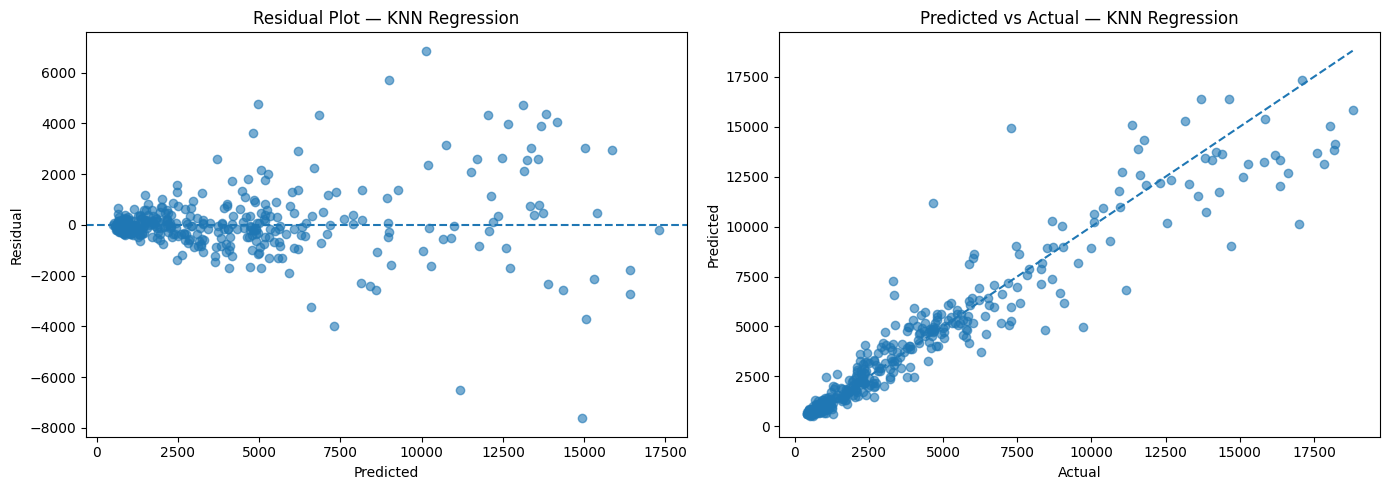

In [9]:
residuals = y_test - pred
fig, axes = plt.subplots(1,2, figsize=(14,5))
axes[0].scatter(pred, residuals, alpha=0.6)
axes[0].axhline(0, linestyle="--")
axes[0].set_title("Residual Plot — KNN Regression")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Residual")
axes[1].scatter(y_test, pred, alpha=0.6)
lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
axes[1].plot(lims, lims, linestyle="--")
axes[1].set_title("Predicted vs Actual — KNN Regression")
axes[1].set_xlabel("Actual")
axes[1].set_ylabel("Predicted")
plt.tight_layout()
plt.show()

### Diagnostic observation — comment on residual structure and distance of points from the diagonal.

In [10]:
root = Path("..") if Path("../data").exists() else Path(".")
(root/"results").mkdir(parents=True, exist_ok=True)
(root/"models").mkdir(parents=True, exist_ok=True)

joblib.dump(pipeline, root/"models"/"knn_regression_baseline.joblib")

pd.DataFrame([{
    "Model":"KNN Regression",
    "R2":r2, "RMSE":rmse, "MAE":mae,
    "CV_R2_Mean":cv_scores.mean(),
    "CV_R2_Std":cv_scores.std(),
    "Tuned_R2":tuned_r2,
    "Tuned_RMSE":tuned_rmse,
    "Tuned_MAE":tuned_mae,
    "Best_k":search.best_params_["model__n_neighbors"]
}]).to_csv(root/"results"/"regression_knn_results.csv", index=False)

print("Saved model and result CSV.")

Saved model and result CSV.
